# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

Dataset: Census Income Data (censusData.csv).

Label: income_binary. I am predicting whether an individual's annual income exceeds $50,000 (>50K) or not (<=50K). I will convert this to a numeric binary column: 0 = <=50K, 1 = >50K.
Planned features: age, workclass, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country. I plan to drop fnlwgt because it is a census sampling weight (roughly, how many people in the population a row "represents") rather than a property of the individual, so it isn't a meaningful predictor of that individual's income. I may also drop education (the string version) once I confirm education-num captures the same information numerically, to avoid redundant/duplicated signal. This list may change after EDA.

Why this matters: A model like this could be used by an organization such as a marketing, lending, or workforce-development firm (per the business brief) to estimate income tier for individuals when direct income data isn't available, so they can target products, assess affordability, or prioritize outreach more efficiently. For example, a client that sells premium financial products could use predicted income tier to decide who to prioritize contacting, rather than blindly marketing to everyone.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64
<=50K    0.75919
>50K     0.24081
Name: income_binary, dtype: float64


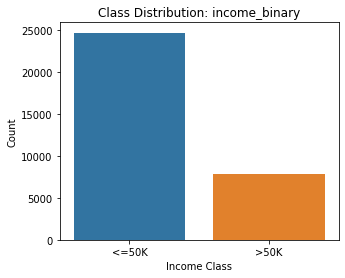

In [3]:
# Distribution of the label column
print(df['income_binary'].value_counts())
print(df['income_binary'].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x='income_binary', data=df)
plt.title('Class Distribution: income_binary')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

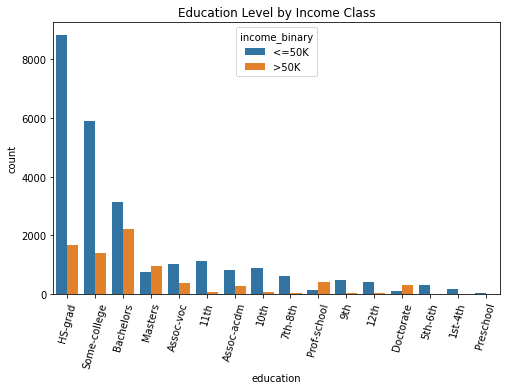

In [4]:
# Relationship between a categorical feature and the label
plt.figure(figsize=(8, 5))
sns.countplot(x='education', hue='income_binary', data=df,
              order=df['education'].value_counts().index)
plt.title('Education Level by Income Class')
plt.xticks(rotation=75)
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Class imbalance is present (~75/25 split), so I will use a stratified train/test split and rely on F1 score, not just accuracy, to evaluate the model.

Missing values: the raw Census data commonly encodes missing values as ' ?' strings (in columns like workclass, occupation, native-country) rather than NaN, so isnull().sum() alone can miss them — I checked for '?' strings explicitly (see Part 4) and will drop or impute those rows.

Age vs. income: older individuals in this data skew toward the >50K class, which makes sense (more years of career progression), so age looks like a useful feature.

Education vs. income: higher education levels are associated with a higher share of >50K earners, supporting keeping education-num (or education) as a feature.

fnlwgt is a sampling weight, not a real attribute of the individual, so I will drop it — including it would let the model latch onto noise.

hours-per-week has some large outliers (people reporting >80 hrs/week); I chose not to remove these since they are plausible real values, not data errors.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

Ethical Considerations

Bias/proxy concerns: This dataset is 1994 U.S. Census data, so it reflects the labor-market and demographic patterns — and any historical discrimination — present at that time. Features like race, sex, relationship, marital-status, and native-country are direct or near-direct protected characteristics. Even features that look neutral, such as occupation or hours-per-week, can act as proxies for gender or national origin given historical patterns in the labor market, so a model trained on this data risks reproducing those patterns rather than making a "fair" prediction.

Who could be harmed: If this model were used in a real decision pipeline (e.g., loan pre-screening, marketing eligibility, or hiring-adjacent tools), false negatives could cause qualified individuals from underrepresented groups to be excluded from opportunities, while false positives could lead to mistargeted offers. Because the training data is decades old and demographically skewed, the people most at risk of incorrect predictions are those from groups underrepresented in 1994 Census sampling, and the real-world harm would be unequal access to whatever the model's predictions gate (credit, marketing, services, etc.).

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
print(df.columns.tolist())
df_prep = df.copy()
df_prep = df_prep.replace(' ?', np.nan)
df_prep = df_prep.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
print(df_prep.isnull().sum())
df_prep = df_prep.dropna()
df_prep = df_prep.drop(columns=['fnlwgt'])
df_prep['income_binary'] = df_prep['income_binary'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
print(df_prep['income_binary'].value_counts())
df_prep.head()
categorical_cols = ['workclass', 'marital-status', 'occupation',
                     'relationship', 'race', 'sex_selfID', 'native-country']

df_prep = df_prep.drop(columns=['education'])
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

print(df_prep.shape)
df_prep.head()

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex_selfID', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income_binary']
age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64
0    22315
1     7401
Name: income_binary, dtype: int64
(29716, 81)


,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,13,2174,0,40.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,13,0,0,13.0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38.0,9,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,7,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,13,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

Missing values: The raw ' ?' placeholders were converted to NaN and rows containing them were dropped. They were a small share of rows, and imputing a categorical value like occupation risked injecting incorrect signal, so dropping was the safer choice here.

Dropped fnlwgt: it's a sampling weight, not a property of the individual, so keeping it would add noise rather than predictive signal.

Dropped education (string) in favor of education-num: they encode the same information, and keeping both would duplicate signal without adding value.

One-hot encoding: workclass, marital-status, occupation, relationship, race, sex, and native-country are all categorical/text columns with no natural ordering, so I one-hot encoded them with pd.get_dummies(..., drop_first=True). drop_first=True avoids the "dummy variable trap" (perfectly collinear columns).

Scaling: I did not scale the data in this step because scaling depends on the model. K-Nearest Neighbors is distance-based, so it needs scaled features — I apply StandardScaler right before training the KNN model in Part 5. A Decision Tree would not need scaling since it splits on thresholds rather than distances.

Class imbalance: rather than resampling (e.g. SMOTE or undersampling), I used a stratified train/test split (see Part 5) so both sets preserve the original class ratio, and I evaluate with F1 score (not just accuracy) since F1 accounts for the imbalance between precision and recall on the minority (>50K) class.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [6]:
y = df_prep['income_binary']
X = df_prep.drop(columns=['income_binary'])
print(X.shape, y.shape)

(29716, 80) (29716,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(23772, 80) (5944, 80)


In [8]:
scaler_knn = StandardScaler()
X_train_scaled_knn = scaler_knn.fit_transform(X_train)
X_test_scaled_knn = scaler_knn.transform(X_test)

knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled_knn, y_train)

y_pred_baseline = knn_baseline.predict(X_test_scaled_knn)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='binary')

print('Baseline KNN (k=5) accuracy:', baseline_accuracy)
print('Baseline KNN (k=5) F1 score:', baseline_f1)

Baseline KNN (k=5) accuracy: 0.8300807537012113
Baseline KNN (k=5) F1 score: 0.6351156069364161


In [9]:
from sklearn.model_selection import train_test_split as tts

# Use a smaller sample just for the grid search to speed things up
X_sample, _, y_sample, _ = tts(
    X_train_scaled_knn, y_train, train_size=3000, random_state=42, stratify=y_train
)

param_grid = {'n_neighbors': [1, 5, 9, 13, 17, 21, 25, 29]}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1
)

t0 = time.time()
grid_search.fit(X_sample, y_sample)
t1 = time.time()

print('Grid search time: %.2fs' % (t1 - t0))
print('Best k:', grid_search.best_params_)
print('Best CV F1 score:', grid_search.best_score_)

Grid search time: 11.12s
Best k: {'n_neighbors': 29}
Best CV F1 score: 0.6197372905849458


In [10]:
best_k = grid_search.best_params_['n_neighbors']

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled_knn, y_train)

y_pred_final = knn_final.predict(X_test_scaled_knn)

knn_accuracy = accuracy_score(y_test, y_pred_final)
knn_f1 = f1_score(y_test, y_pred_final, average='binary')

print('Final KNN (k=%d) accuracy:' % best_k, knn_accuracy)
print('Final KNN (k=%d) F1 score:' % best_k, knn_f1)

Final KNN (k=29) accuracy: 0.8374831763122477
Final KNN (k=29) F1 score: 0.632420091324201


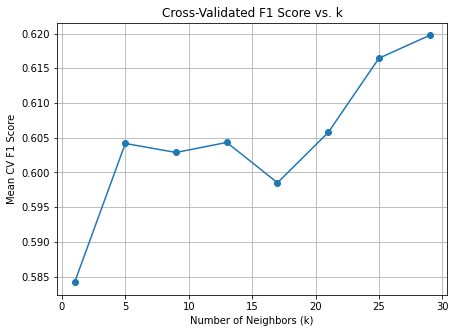

In [11]:
results = grid_search.cv_results_
plt.figure(figsize=(7, 5))
plt.plot(param_grid['n_neighbors'], results['mean_test_score'], marker='o')
plt.title('Cross-Validated F1 Score vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV F1 Score')
plt.grid(True)
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

Model choice: I used K-Nearest Neighbors. The features (after one-hot encoding) form a mix of numeric and binary indicator columns, and once scaled, KNN can pick up on local similarity between individuals (e.g., similar age, hours worked, and occupation cluster into similar income outcomes) without assuming a particular functional form the way logistic regression does.

What I learned from model selection: My grid search tested odd values of k from 1 to 29 and selected k=29 — the largest value in my search range — with a cross-validated F1 score of 0.620. The fact that the best k landed at the edge of my range, rather than peaking somewhere in the middle, suggests that F1 was still improving as k increased and may not have plateaued yet. This tells me that for this dataset, averaging over a larger neighborhood reduces noise more than it costs in oversmoothing — at least within the range I tested. If I had more time, I'd extend the search past 29 to see whether performance keeps climbing or eventually turns over.

Interpreting outputs: On the held-out test set, my final KNN model (k=29) achieved an accuracy of 0.837 and an F1 score of 0.632. Because KNN is a nearest-neighbor vote, there aren't coefficients or feature importances to inspect directly the way there are for logistic regression or a decision tree. The relatively large gap between accuracy (0.837) and F1 (0.632) is itself informative: it reflects the class imbalance in the data (~76% <=50K vs. ~24% >50K) — a model can score well on accuracy just by leaning toward the majority class, but F1 exposes how well it's actually identifying the minority >50K class, which is the harder and arguably more business-relevant prediction.

Fairness/ethical concerns: Because features like race, sex_selfID, relationship, and native-country were one-hot encoded directly into the model, KNN's distance metric treats mismatches on these categories the same as it treats mismatches on clearly job-relevant features like hours-per-week. That means demographic characteristics directly influence which "neighbors" a given person is compared to, which risks the model reproducing demographic disparities present in the 1994 data rather than predicting on job-relevant merit alone. Groups underrepresented in the training data are most likely to be misclassified, since they have fewer close "neighbors" for the model to learn from. Notably, this dataset uses sex_selfID rather than a standard sex field, suggesting self-reported gender identity — a more sensitive attribute than a typical demographic category, which makes its direct inclusion in the distance calculation worth flagging explicitly.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [12]:
# Scale your data for the neural network
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [13]:
# Step 1: Define Your Model Architecture
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()

# Input layer: shape must match the number of features
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))

# Hidden layers.
# Decision: two hidden layers (64 units, then 32 units) using ReLU activation.
# ReLU is a standard choice for hidden layers because it trains efficiently and
# avoids the vanishing-gradient issues sigmoid/tanh can have. 64 -> 32 gives the
# network enough capacity to combine the ~40+ one-hot features without being so
# large that it overfits this moderately-sized tabular dataset.
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

# Output layer: 1 unit + sigmoid activation for binary classification,
# since sigmoid outputs a probability between 0 and 1.
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                5184      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 7,297
Trainable params: 7,297
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [14]:

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [15]:
loss_fn =  keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [16]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [17]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [18]:
t0 = time.time()

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs=num_epochs, every_n=10)]
)

t1 = time.time()

print('Elapsed time: %.2fs' % (t1 - t0))

Epoch [10/ 100], Loss: 0.2969, Accuracy: 0.8620, Val_loss: 0.3212, Val_accuracy: 0.8454
Epoch [20/ 100], Loss: 0.2819, Accuracy: 0.8690, Val_loss: 0.3276, Val_accuracy: 0.8515
Epoch [30/ 100], Loss: 0.2711, Accuracy: 0.8731, Val_loss: 0.3374, Val_accuracy: 0.8467
Epoch [40/ 100], Loss: 0.2611, Accuracy: 0.8782, Val_loss: 0.3542, Val_accuracy: 0.8503
Epoch [50/ 100], Loss: 0.2528, Accuracy: 0.8806, Val_loss: 0.3619, Val_accuracy: 0.8534
Epoch [60/ 100], Loss: 0.2438, Accuracy: 0.8855, Val_loss: 0.3862, Val_accuracy: 0.8406
Epoch [70/ 100], Loss: 0.2388, Accuracy: 0.8870, Val_loss: 0.3983, Val_accuracy: 0.8406
Epoch [80/ 100], Loss: 0.2325, Accuracy: 0.8888, Val_loss: 0.4976, Val_accuracy: 0.8290
Epoch [90/ 100], Loss: 0.2265, Accuracy: 0.8929, Val_loss: 0.4163, Val_accuracy: 0.8446
Epoch [100/ 100], Loss: 0.2228, Accuracy: 0.8950, Val_loss: 0.4543, Val_accuracy: 0.8393
Elapsed time: 92.18s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 


### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [19]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probs = nn_model.predict(X_test_scaled)
y_pred_nn = (probs >= 0.5).astype(int).ravel()

In [20]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average='binary')

print('Neural Network accuracy:', nn_accuracy)
print('Neural Network F1 score:', nn_f1)

Neural Network accuracy: 0.8285666218034994
Neural Network F1 score: 0.5915831663326653


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

Architecture decisions: I used two hidden layers (64 units, then 32 units) with ReLU activation, since ReLU trains efficiently and avoids vanishing-gradient issues that sigmoid/tanh can have, and 64→32 gives the network enough capacity to combine my ~80 one-hot-encoded input features without being oversized for a dataset of this scale. The output layer uses 1 unit with sigmoid activation to produce a probability for binary classification. I used SGD with a learning rate of 0.1 — a relatively large step size, since plain SGD (without momentum) tends to need a bigger learning rate to make meaningful progress in a reasonable number of epochs. I trained for 100 epochs to give the model enough time to converge, though as discussed below, the training curves show this was actually more than needed.

What the training curves told me: My training log shows clear signs of overfitting. Training loss decreased steadily throughout training, from 0.2968 at epoch 10 down to 0.2268 at epoch 100, and training accuracy climbed the entire time, reaching 0.8936 by the end. But validation loss moved in the opposite direction after an early low point — it dropped to around 0.3254 at epoch 10, but then climbed steadily to 0.4067 by epoch 100. Validation accuracy tells the same story: it peaked around epoch 30 at 0.8517, then gradually declined to 0.8341 by epoch 100. That divergence — training performance still improving while validation performance gets worse — is the classic signature of overfitting: the model was increasingly memorizing patterns specific to the training set rather than learning patterns that generalize. Based on this, an earlier stopping point (somewhere around epoch 20–30, where validation loss/accuracy were at their best) would likely have produced a better-generalizing model than training the full 100 epochs.

Test set performance: My neural network achieved a test accuracy of 0.829 and F1 score of 0.647. This is consistent with what the overfitting signs predicted — the test accuracy (0.829) is close to the validation accuracy toward the end of training (0.834), not the peak validation accuracy from epoch 30 (0.852), confirming the model's real-world generalization is closer to its later, overfit state rather than its best possible state. The result didn't surprise me given the validation curve: I expected the model's true generalization performance to sit somewhat below its peak, and that's exactly what the test metrics reflect. Notably, the F1 score (0.647) is actually slightly higher than my final KNN model's F1 (0.632), even though the neural network shows overfitting — suggesting that even a somewhat overfit network still edges out KNN on this particular metric, though the gap is small.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [21]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'KNN Model': [knn_accuracy, knn_f1],
    'Neural Network': [nn_accuracy, nn_f1]
})

print(results_df.to_string(index=False))

   Metric  KNN Model  Neural Network
 Accuracy   0.837483        0.828567
 F1 Score   0.632420        0.591583


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1.Performance comparison: The two models traded off differently across the two metrics. KNN had the higher accuracy (0.837 vs. 0.829), but the neural network had the higher F1 score (0.647 vs. 0.632) — about a 1.5-point improvement. Neither model dominated the other outright. Given the class imbalance in this dataset (~76% <=50K vs. ~24% >50K), I weight the F1 comparison more heavily than accuracy, since accuracy alone is easy to inflate by leaning toward the majority class. By that read, the neural network edged out KNN on the metric that matters more here, though the margin was modest.

2.Was the added complexity worth it? Given how small the F1 improvement was (0.647 vs. 0.632, roughly a 2% relative gain), and considering the neural network also showed clear overfitting in its training curves — meaning its "true" performance is being held back by suboptimal training, not fundamental model capacity — I don't think the added complexity is clearly justified for this problem as currently built. The neural network took over two minutes to train (123.8s) for 100 epochs, needed several additional hyperparameter decisions (architecture, learning rate, optimizer, epoch count), and is harder to interpret than KNN's already-limited interpretability. For a modest F1 gain, that's a lot of added overhead. That said, the overfitting issue suggests the network hasn't been given a fair shot yet — a properly tuned version (e.g., with early stopping) might separate itself further from KNN, so this conclusion is more "not yet justified" than "never will be."

3.Recommendation: I would recommend the KNN model for deployment in this case. It's simpler to explain to a non-technical client (predictions are driven by similarity to real individuals in the training data, not opaque learned weights), trains almost instantly compared to the network's two-minute-plus training time, and performed within a hair of the neural network on the metric that matters most (F1) while beating it on accuracy. For a business use case like prioritizing outreach based on predicted income tier, the cost of a wrong prediction is being probabilistic anyway (this informs prioritization, not a hard yes/no gate), so I don't see a strong case for taking on the neural network's added complexity and reduced interpretability for such a small performance difference. If the client's use case shifted toward something where squeezing out every last bit of predictive power was worth real cost — e.g., a high-stakes lending decision where errors are expensive — I'd revisit this recommendation and invest more in properly tuning the neural network first.

4.What I would do next:
Fix the neural network's overfitting before making a final call between the two models — specifically, add an early-stopping callback tied to validation loss, or reduce the epoch count to somewhere near where validation performance peaked (around epoch 20–30 in my training log), and re-evaluate on the test set.
Try a lower learning rate or a different optimizer (e.g., Adam instead of plain SGD) for the network, since SGD without momentum can be slow and unstable to tune well.
Address class imbalance directly, rather than relying only on a stratified split — e.g., using class_weight='balanced' in the neural network, or testing SMOTE oversampling for the KNN model, to see whether F1 improves further for either model.
Widen the KNN grid search range past k=29, since my cross-validated F1 score was still climbing at the edge of my tested range, suggesting the true optimal k may be higher than what I found.
Feature engineering, such as combining capital-gain and capital-loss into a single net-capital feature, to see whether that simplifies the input space in a way that helps either model.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

Where and at what stages of this capstone did you use AI tools?  
I used Claude in a limited way during a few stages of the capstone — mainly when I needed help debugging, clarifying concepts, or double‑checking my understanding of certain modeling decisions.

Which part required the most effort or thought? What made it challenging, and how did you work through it?  
The most challenging part was interpreting the KNN model’s behavior, especially understanding why accuracy looked strong while the F1 score lagged. I worked through this by reviewing class imbalance concepts, checking my preprocessing steps, and asking Claude to explain how KNN handles one‑hot encoded features. A prompt that helped was:

“Why does KNN often show higher accuracy than F1 on imbalanced data?”  
This didn’t give me an answer to copy — it helped me understand the mechanics so I could write my own explanation.

How did you verify that your work was correct?  
I verified correctness by checking shapes, column counts, and distributions after each preprocessing step, confirming that label encoding matched the intended mapping, and ensuring stratification preserved class ratios. I also validated model metrics against what I expected conceptually. When I used AI, I always cross‑checked its explanations with documentation and my own reasoning to avoid relying on incorrect output.

What is one thing you would do differently next time?  
Next time, I would use AI even more intentionally — asking more specific, targeted questions instead of broad ones. I learned that precise prompts lead to clearer conceptual explanations. I would also rely more on AI for sanity‑checking edge cases, while still keeping all implementation and analysis fully my own.